In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('train.csv')
df.shape

(594194, 21)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [82]:
df = df.drop('id',axis=1)

In [83]:
df.columns = df.columns.str.lower()

In [84]:
df.churn.value_counts(normalize=True)

churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In [85]:
df.duplicated().sum()

0

In [86]:
df.isna().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [87]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [88]:
for col in cat_cols:
    print(df[col].value_counts())
    print('--'*50)

gender
Female    298738
Male      295456
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
partner
Yes    309554
No     284640
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
dependents
No     414362
Yes    179832
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
phoneservice
Yes    557893
No      36301
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
multiplelines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
internetservice
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
-----

In [89]:
target = 'churn'
num_cols = df.select_dtypes(include=np.number).columns.tolist()
binary_cols = ['partner','dependents','paperlessbilling','phoneservice']
ohe_cols = [col for col in df.columns
           if col not in num_cols and col not in binary_cols and col not in target]

In [90]:
print('Numeric:', num_cols)
print('binary_cols:', binary_cols)
print('cat_cols:', ohe_cols)
print('target :', target)

Numeric: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']
binary_cols: ['partner', 'dependents', 'paperlessbilling', 'phoneservice']
cat_cols: ['gender', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paymentmethod']
target : churn


In [91]:
X = df.drop(columns=[target], axis=1)
y = df[target]

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11, stratify=y)

In [93]:
df.sample()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
82268,Female,0,Yes,No,63,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),108.0,6669.05,No


In [94]:
X_train[binary_cols] = X_train[binary_cols].replace({'Yes':1, 'No':0})
X_test[binary_cols] = X_test[binary_cols].replace({'Yes':1, 'No':0})

In [95]:
import warnings
warnings.filterwarnings('ignore')

In [96]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

scaler = StandardScaler()
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
binary_transformer = 'passthrough'

y_train = y_train.map({'Yes':1, 'No':0})
y_test = y_test.map({'Yes':1, 'No':0})

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('binary', binary_transformer, binary_cols),
        ('ohe', ohe, ohe_cols)
    ])



## LogisticRegression

In [97]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=11)),
    ('model', LogisticRegression(max_iter=700))
])

pipe.fit(X_train,y_train)
train_score = pipe.score(X_train, y_train)


test_score = pipe.score(X_test,y_test)
print('train_score :', train_score)
print('test_score :', test_score)

train_score : 0.8081812540101608
test_score : 0.8075126852295963


In [98]:
y_train.isna().sum()

0

## RandomForest

In [102]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

tree_processor = ColumnTransformer(
    transformers=[        
        ('binary', binary_transformer, binary_cols),
        ('ohe', ohe, ohe_cols)
    ], remainder='passthrough')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


pipe = Pipeline(steps=[
    ('preprocess', tree_processor),    
    ('smote', SMOTE(random_state=11)),
    ('model', rf)
])

pipe.fit(X_train,y_train)
train_score = pipe.score(X_train, y_train)


test_score = pipe.score(X_test,y_test)
print('train_score :', train_score)
print('test_score :', test_score)



train_score : 0.8536041484785055
test_score : 0.8458923417396645


## LightGBM

In [105]:
lgb = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    is_unbalance=True,
    random_state=42
)


pipe = Pipeline(steps=[
    ('preprocess', tree_processor),    
    ('smote', SMOTE(random_state=11)),
    ('model', lgb)
])

pipe.fit(X_train,y_train)
train_score = pipe.score(X_train, y_train)


test_score = pipe.score(X_test,y_test)
print('train_score :', train_score)
print('test_score :', test_score)



[LightGBM] [Info] Number of positive: 368301, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6229
[LightGBM] [Info] Number of data points in the train set: 736602, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
train_score : 0.8601781826214092
test_score : 0.857462617490891


## XGB

In [109]:
neg, pos = np.bincount(y_train)
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)
pipe = Pipeline(steps=[
    ('preprocess', tree_processor),    
       ('model', xgb)
])

pipe.fit(X_train,y_train)
train_score = pipe.score(X_train, y_train)


test_score = pipe.score(X_test,y_test)
print('train_score :', train_score)
print('test_score :', test_score)



train_score : 0.8222949164308779
test_score : 0.81820782739673


## CatBoost

In [110]:
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)
pipe = Pipeline(steps=[
    ('preprocess', tree_processor),    
        ('model', cat)
])

pipe.fit(X_train,y_train)
train_score = pipe.score(X_train, y_train)


test_score = pipe.score(X_test,y_test)
print('train_score :', train_score)
print('test_score :', test_score)



train_score : 0.8618947944168043
test_score : 0.8610641287792729


In [112]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -----------------------------
# Preprocessor
# -----------------------------
tree_processor = ColumnTransformer(
    transformers=[
        ('binary', 'passthrough', binary_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols)
    ],
    remainder='passthrough'
)

# -----------------------------
# Models
# -----------------------------
neg, pos = y_train.value_counts()
scale = neg / pos

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=-1,
        is_unbalance=True,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='AUC',
        random_state=42,
        verbose=0
    )
}

# -----------------------------
# Evaluation loop
# -----------------------------
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', tree_processor),
        ('smote', SMOTE(random_state=11)),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

[LightGBM] [Info] Number of positive: 368301, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6229
[LightGBM] [Info] Number of data points in the train set: 736602, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
          Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  RandomForest  0.845892   0.632775  0.752270  0.687368  0.910256
1       XGBoost  0.812545   0.552517  0.881740  0.679343  0.913878
2      LightGBM  0.857463   0.683984  0.682323  0.683152  0.913759
3      CatBoost  0.856840   0.677972  0.693906  0.685846  0.913526


In [114]:

# predicted probabilities from your XGBoost pipeline
y_prob = pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)
rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.403058,0.977170,0.570712
1,0.10,0.461537,0.953219,0.621939
2,0.15,0.504647,0.927138,0.653558
3,0.20,0.535764,0.898666,0.671309
4,0.25,0.564523,0.868774,0.684356
5,0.30,0.590132,0.838882,0.692857
6,0.35,0.612456,0.807271,0.696497
7,0.40,0.634276,0.773157,0.696865
8,0.45,0.655783,0.736203,0.693670
9,0.50,0.677972,0.693906,0.685846


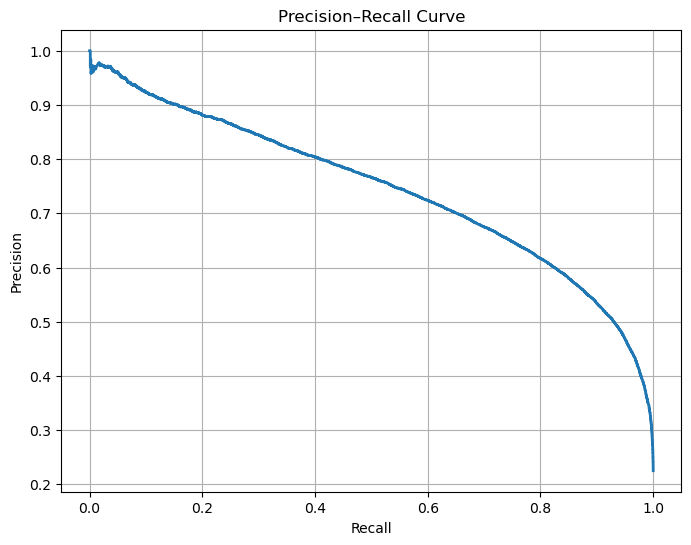

In [115]:

from sklearn.metrics import precision_recall_curve

precision, recall, thresh = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()